# INSIGHT 심화세션 사전과제
## 06. 생성 모델

## <span style="background-color:#F993C0; color:#311d26; padding:4px; border-radius:0px;"> 생성 모델 </span>

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> 분류모델과 생성모델의 차이 </span>

분류 모델: 입력된 데이터(𝑥)가 어떤 레이블(𝑌, 정답)에 속할지 결정하는 모델

- 학습 목표: P(Y∣X) 모델링 (데이터 X가 주어졌을 때 정답 Y일 확률 계산).
- 한계 : 본 적 없는 이상한 데이터(예: 외계인 그림)가 들어와도, 모델은 어떻게든 기존에 배운 라벨(고양이 혹은 개) 중 하나로 결론을 내려야만 합니다.

생성 모델: 데이터 자체의 확률 분포 P(x)를 학습하여, 학습 데이터와 유사한 새로운 데이터를 만들어내는 모델

- 학습 목표: P(X) 모델링 (세상에 존재할 법한 데이터 X 자체의 확률 분포 파악)
- 특징: 불합리하거나 이상한 입력(Unreasonable input)에 대해서는 "이건 세상에 존재할 확률이 거의 0이야"라고 판단하며 거부할 수 있는 능력을 갖춥니다.

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> 생성모델의 분류 </span>

"확률 밀도(Probability Density)를 직접 계산할 수 있는가?"에 따라 명시적 모델과 암시적 모델로 분류

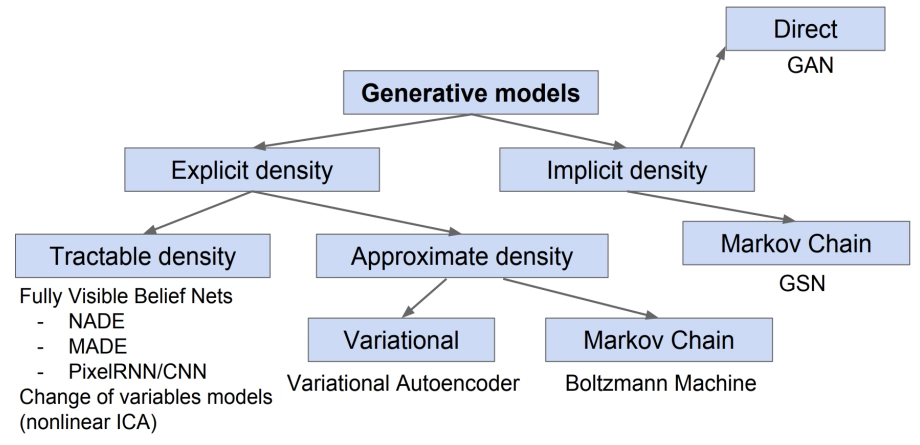

#### AE

오토인코더는 입력과 동일한 출력을 만드는 것을 목적으로 하는 신경망

- 차원 축소, 특징 추출, 노이즈 제거, 이상 탐지 등 데이터 복원이나 특성 학습에 많이 사용

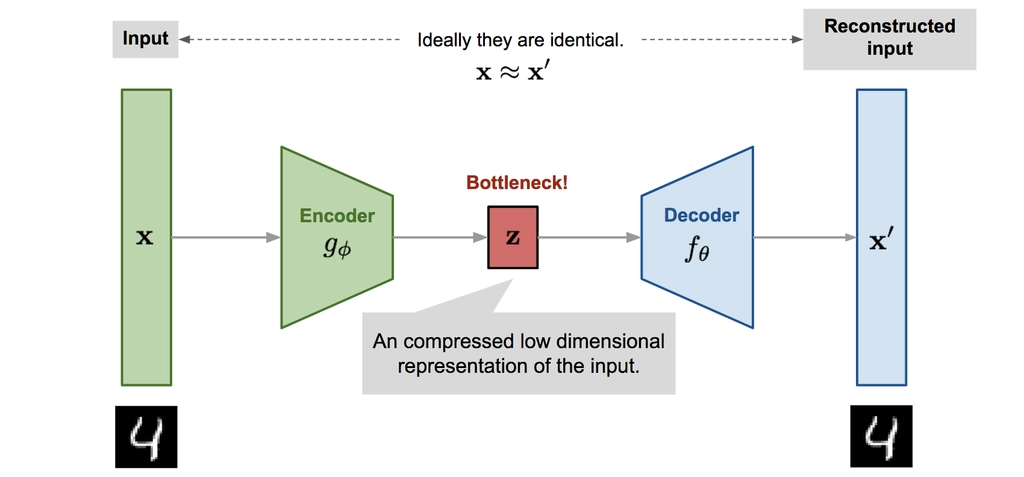

[Step 1] 압축 단계 (Encoder)   
[Step 2] 병목 통과 (Bottleneck)   
[Step 3] 복원 단계 (Decoder)

-> AE는 인코더로 들어가는 입력 데이터 (𝑥)와 디코더가 출력한 데이터(𝑥′)가 같아지도록 훈련하여 그 과정에서 데이터의 가장 중요한 특징(잠재 벡터)만 남기게 되는 모델

#### VAE

VAE는 데이터의 잠재적인 구조를 학습하여, 원본과 닮았지만 새로운 데이터를 생성해내는 모델

- AE는 데이터를 잠재 공간의 특정 점으로만 보냄
- VAE의 해결책: 잠재 벡터를 점이 아닌 가우시안 분포(범위)로 학습
- 이미지 생성, 텍스트 생성, 신호 처리, 이미지 보간 등 새로운 데이터를 생성하는 작업에 많이 사용

| **구분** | **Auto Encoder (AE)** | **Variational Auto Encoder (VAE)** |
| --- | --- | --- |
| **주인공** | **인코더 (압축이 중요)**
***디코더**는 압축이 잘되었는지 검사하는 역할* | **디코더 (생성이 중요)**
***인코더**는 디코더를 잘 학습시키기 위한 가이드* |
| **잠재 벡터 $z$의 형태** | **고정된 수치 (Point)** | **확률 분포 (Distribution)** |
| **잠재 공간의 특성** | 불연속적이고 비어있는 공간이 많음 | 연속적이며 표준 정규 분포를 따름 |
| **샘플링 결과** | 학습 데이터 외 구역에서는 복원이 불가능함 | 어느 지점에서든 의미 있는 생성이 가능함 |
| **주요 효과** | 데이터 압축 및 특징 추출 | **데이터 생성 및 보간 (Interpolation)** |

#### GAN

GAN(Generative Adversarial Network, 생성적 적대 신경망): 생성자 신경망과 판별자 신경망이 서로 적대적으로 경쟁하면서, 훈련을 통하여 자신의 작업을 점점 더 정교하게 수행하는 신경망 모델

- 생성자(Generator)의 목적은 진짜 분포에 가까운 가짜분포를 생성하는 것
- 판별자(Discriminator)의 목적은 표본이 가짜 분포에 속하는지 진짜 분포에 속하는지를 결정하는 것

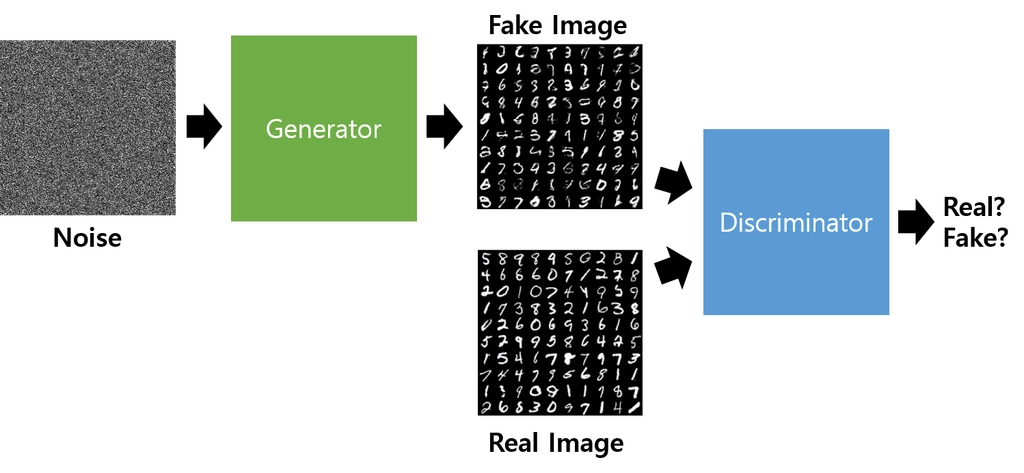

- GAN은 두 개의 신경망이 최소-최대 게임(MinMax Game)을 수행하는 구조

[GAN의 장점]

- 진짜 같은 가짜를 생성 가능
- 압도적인 선명도
- 빠른 생성 속도
- 잠재공간의 부드러움

[GAN의 한계점]
- 학습의 불안정성
- 훈련 초기 문제
- 모드 붕괴
- 지표의 부재
- 역매핑 불가능

#### 확산모델

확산 모델(Diffusion Model):    
1️⃣ 입력 이미지에 노이즈를 조금씩 추가하여 완전한 노이즈로 만든 뒤,    
2️⃣ 이를 다시 거꾸로 복원하는 과정을 학습하여 (노이즈 제거)   
3️⃣ 입력 이미지와 유사한 확률 분포를 가진 결과 이미지를 생성하는 모델   

확산 모델의 흐름 : 원본 데이터→ 완전한 노이즈 → 원본 데이터

[확산 모델의 구조]

1) 순확산 (Forward Diffusion Process)
- 순확산 과정은 데이터에 점진적으로 (정규분포를 가진)노이즈를 추가하는 과정
- 이 과정의 목표는 원래 데이터를 점차적으로 무작위 노이즈로 변형시키는 것

2) 역확산 (Reverse Diffusion Process) 
- 노이즈 데이터에서 원본 데이터를 재구성하는 과정
-  이 과정의 목표는 순확산 과정에서 추가된 노이즈를 제거하여 원래의 데이터를 복원하는 것

## <span style="background-color:#F993C0; color:#311d26; padding:4px; border-radius:0px;"> AI 최적화 </span>

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> 전이학습 </span>

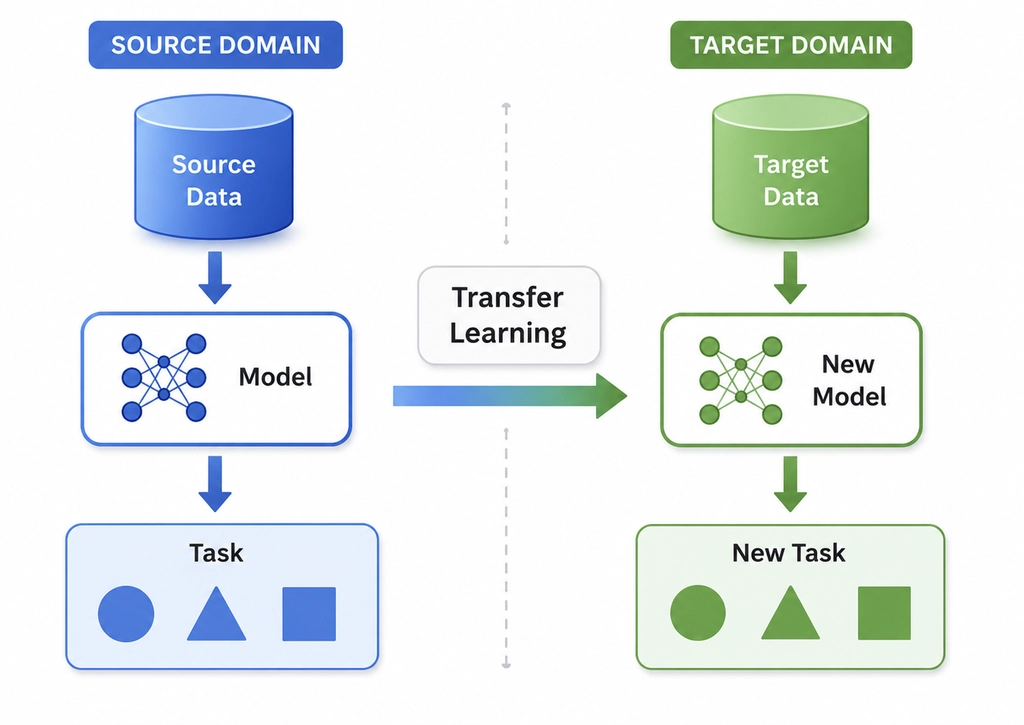

데이터나 문제 유형이 달라도 다른 상황에서 배운 지식을 가져와서 새로운 상황에서 성능을 높이는 것

-> 따라서 전이학습은 Domain과 Task 중에 하나라도 다를 때 의미가 생김!

#### 개념과 분류

도메인과 태스크에 따른 분류
전이학습을 분류할 때, 도메인과 태스크의 상태에 따라 다음과 같이 구분 가능

1. 귀납적 전이학습 (Inductive TL)   
: 소스와 타겟의 task가 다르고 타겟 도메인에 라벨이 존재할 때

2. 트랜스듀서형 전이학습 (Transductive TL)   
: 소스와 타겟의 task는 같지만 도메인이 다를 때

3. 비지도 전이학습 (Unsupervised TL)   
: 소스와 타겟의 task가 다르고 소스와 타겟 모두 라벨이 없을 때 

| 분류 | Domain | Task | 라벨 |
| --- | --- | --- | --- |
| 귀납적 전이학습 | 같거나 다름 | **다름** | 타겟에 라벨 있음 |
| 트랜스듀서형 전이학습 | **다름** | 같음 | 타겟에 라벨 없음 |
| 비지도 전이학습 | 다름 | 다름 | **둘 다 라벨 없음** |

무엇을 전이하느냐에 따라서도 다음과 같이 구분 가능

1. 인스턴스(Instance): 소스 데이터 중 타겟에 도움이 될만한 샘플을 골라 가중치를 부여

2. 특징(Feature): 소스와 타겟의 공통적인 특징을 추출할 수 있는 '표현 방식'을 전이

3. 파라미터(Parameter): 모델의 가중치(𝑊)나 하이퍼파라미터 초기값을 그대로 가져옴

4. 관계(Relation): 데이터 간의 논리적 관계나 구조적 지식을 전이

| 전이 방식 | 뭘 옮기는가 | 예시 |
| --- | --- | --- |
| **인스턴스** | 소스 데이터 중 쓸만한 샘플 | 영어 뉴스 데이터 중 한국어랑 비슷한 문장만 골라서 가져옴 |
| **특징** | 데이터를 표현하는 방식 | 이미지에서 선·면을 찾는 능력을 가져옴 |
| **파라미터** | 모델의 가중치 자체 | 가중치 그대로 가져다가 Fine-tuning ← **현재 주류!** |
| **관계** | 데이터 간의 논리적 구조 | "A는 B의 부분이다" 같은 관계 지식을 가져옴 |

#### Pre-Training과 Fine-tuning

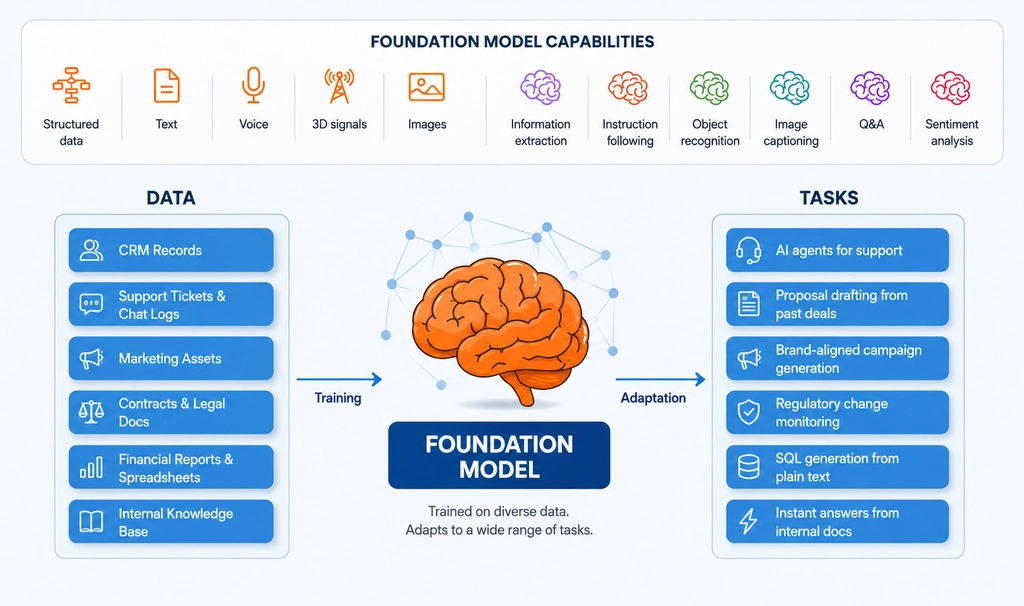

트랜스포머의 등장 이후, 엄청난 양의 데이터로 사전 학습된 거대 모델 (Pre-trained Model) 들이 등장

이전 : "어떻게 지식을 옮기지?"   
이후 : "이미 잘 학습된 거대 모델을 내 용도에 맞게 어떻게 조정하지?"

GPT나 Gemini처럼 수만 가지 일을 할 수 있는 지능의 기반이 되는 거대 모델: Foundation Model(파운데이션 모델)

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> AI Alignment </span>

AI Alignment(인공지능 정렬)는 단순히 모델의 성능을 높이는 단계를 넘어,
AI가 인간의 의도(Intent), 목표(Goal), 그리고 윤리적 가치(Values)에 부합하도록 행동하게 만드는 연구 분야

- 그래서 등장한 현대 정렬의 기준이 되는 세 가지 지표는 Helpful(도움이 되는가) / Honest(정직한가) / Harmless(무해한가)

#### RLHF

RLHF(Reinforcement Learning from Human Feedback)는 이를 해결하기 위해 인간의 피드백을 기반으로 모델을 강화학습으로 조정하는 방법

- SFT → Reward Model → RL 의 3단계로 진행

#### <span style="background-color:#633a4c; color:#fde9f2; padding:4px; border-radius:0px;"> 프롬프트 엔지니어링 </span>

프롬프트 엔지니어링은 AI가 더 좋은 답변을 내도록 입력을 설계하는 기술

|  | 프롬프트 엔지니어링 | Fine-tuning |
| --- | --- | --- |
| 비용 | 낮음 | 높음 |
| 속도 | 빠름 | 느림 |
| 성능 한계 | 있음 | 더 높은 성능 가능 |
| 언제 쓰나 | 빠른 프로토타입, 범용 태스크 | 특화된 도메인, 높은 정확도 필요할 때 |